In [1]:
# import packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import interactive
interactive(True)
import itertools
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
import sklearn.utils
from sklearn.preprocessing import StandardScaler
import math
import seaborn as sns
import scipy as sp
import pickle
import glob
import os
import ast

In [2]:
# load the CCLE TNBC cell line information dataset 
df_tnbc_info = pd.read_csv('updated_TNBC_list_12032022.csv')

In [3]:
# load the Depmap/CCLE Pan-cancer gene expression dataset:
df_exp=pd.read_csv('../../Desktop/EDGE/OmicsExpressionProteinCodingGenesTPMLogp1.csv', index_col=0)
df_exp.columns=[i.split(' (')[0] for i in df_exp.columns]

In [4]:
df_exp.columns

Index(['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112', 'FGR', 'CFH', 'FUCA2',
       'GCLC', 'NFYA',
       ...
       'H3C2', 'H3C3', 'AC098582.1', 'DUS4L-BCAP29', 'C8orf44-SGK3', 'ELOA3B',
       'NPBWR1', 'ELOA3D', 'ELOA3', 'CDR1'],
      dtype='object', length=19193)

In [5]:
#To only select TNBC cell lines from the pan-cancer gene expression dataset:
whole_genome=df_exp.columns.tolist()
df_exp_tnbc=df_exp[df_exp.index.isin(df_tnbc_info.DepMap_ID)]

In [6]:
df_exp_tnbc.head()

,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,H3C2,H3C3,AC098582.1,DUS4L-BCAP29,C8orf44-SGK3,ELOA3B,NPBWR1,ELOA3D,ELOA3,CDR1
ACH-000276,3.935460,0.0,6.519951,2.572890,4.304511,0.084064,2.893362,6.451541,4.237258,4.126808,...,3.017922,2.263034,1.182692,2.286881,0.970854,0.056584,2.776104,0.214125,0.056584,0.333424
ACH-000856,5.705701,0.0,6.413628,3.300124,4.052242,0.124328,3.032101,6.229780,4.637494,4.794936,...,1.608809,0.000000,0.485427,2.646163,0.201634,0.000000,0.056584,0.000000,0.124328,0.000000
ACH-000223,4.903038,0.0,7.177918,2.744161,4.648465,0.150560,0.070389,5.820179,4.374344,3.814550,...,2.440952,1.695994,0.367371,1.505891,0.214125,0.137504,0.704872,0.000000,0.000000,0.000000
ACH-000643,4.499527,0.0,6.054197,2.060047,3.472488,0.263034,3.238787,5.337354,4.208673,4.008989,...,0.632268,0.773996,0.333424,1.778209,0.238787,0.000000,0.084064,0.042644,0.042644,0.000000
ACH-000857,4.866908,0.0,5.723286,1.773996,3.464668,0.176323,0.443607,5.730912,4.418190,3.218781,...,0.659925,1.007196,0.432959,2.201634,0.000000,0.000000,3.442280,0.000000,0.000000,0.000000


In [7]:
len(df_exp_tnbc)

30

Estimated no. of clusters: 5
Estimated no. of noise points: 172


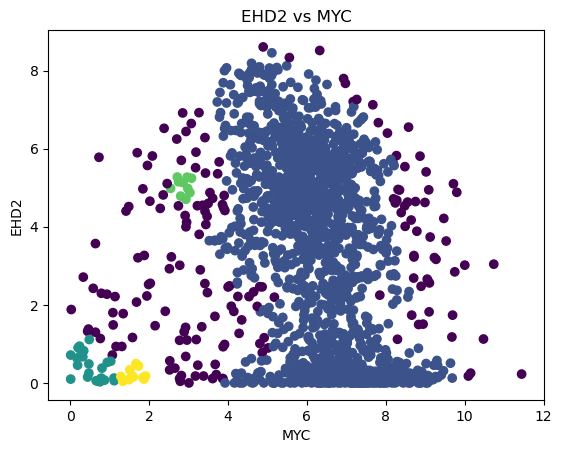

In [8]:
#DBSCAN clustering on gene expression data 
df_tmp = df_exp[['MYC', 'EHD2']]

df_tmp_t = StandardScaler().fit_transform(df_tmp)

db = DBSCAN(eps=0.2, min_samples=10).fit(df_tmp_t)
labels = db.labels_

realClusterNum = len(set(labels)) - (1 if -1 in labels else 0)
clusterNum = len(set(labels))

set(labels)

labels = db.labels_

no_clusters = len(np.unique(labels) )
no_noise = np.sum(np.array(labels) == -1, axis=0)

print('Estimated no. of clusters: %d' % clusterNum)
print('Estimated no. of noise points: %d' % no_noise)

X = df_tmp_t

# Generate scatter plot for training data
plt.scatter(df_tmp['MYC'], df_tmp['EHD2'], c=db.labels_.astype(float), marker="o", picker=True)
plt.title('EHD2 vs MYC')
plt.xlabel('MYC')
plt.ylabel('EHD2')
plt.show()


In [9]:
tnbc_list = df_tnbc_info.DepMap_ID
list_eps=np.arange(0.1, 1.21, 0.01).tolist()
def centeroidnp(arr):
    length = arr.shape[0]
    sum_x = np.sum(arr[:, 0])
    sum_y = np.sum(arr[:, 1])
    return sum_x/length, sum_y/length

In [10]:
gene_index_list=[]
eps_list=[]
cluster_number_list=[]
pan_cancer_distribution_list=[]
TNBC_distribution_list=[]

cluster_combination_list=[]
TNBC_distribution_in_this_cluster_list=[]
centroid_distance_list=[]
cluster_separation_list=[]

for i in whole_genome[4500:4501]:
    for j in list_eps:
        df_tmp = df_exp[['MYC', i]]
        df_tmp_t = StandardScaler().fit_transform(df_tmp)
        db = DBSCAN(eps=j, min_samples=30).fit(df_tmp_t)
        labels = db.labels_
        df_tmp['labels']= labels
        realClusterNum = len(set(labels)) - (1 if -1 in labels else 0)
        clusterNum = len(set(labels))
        
    
    

        
        pan_cancer_distibution={}
        df_dis=df_tmp['labels'].value_counts().to_frame()
        
        for h in df_dis.index.tolist():
            pan_cancer_distibution[str(h)]=df_dis.loc[h, 'count']
        
        
    
        TNBC_distibution={}
        df_tnbc_dis=df_tmp[df_tmp.index.isin(df_tnbc_info.DepMap_ID)]['labels'].value_counts().to_frame()
        for k in df_tnbc_dis.index.tolist():
            TNBC_distibution[str(k)]=df_tnbc_dis.loc[k, 'count']

        if len(set(labels))<2:
            gene_index_list.append(i)
            eps_list.append(j)
            cluster_number_list.append(clusterNum)
            pan_cancer_distribution_list.append(pan_cancer_distibution)
            TNBC_distribution_list.append(TNBC_distibution)
            cluster_combination_list.append(np.nan)
            TNBC_distribution_in_this_cluster_list.append(np.nan)
            cluster_separation_list.append(np.nan)
            centroid_distance_list.append(np.nan)
        else:
            for subset in itertools.combinations(set(labels), 2):
                gene_index_list.append(i)
                eps_list.append(j)
                cluster_number_list.append(clusterNum)
                pan_cancer_distribution_list.append(pan_cancer_distibution)
                TNBC_distribution_list.append(TNBC_distibution)
            
                cluster_combination_list.append(subset)
            
                df_tmp_1=df_tmp[df_tmp.labels==subset[0]]
                df_tmp_2=df_tmp[df_tmp.labels==subset[1]]
            
                TNBC_in_this_cluster_distribution={}
            
                TNBC_in_this_cluster_distribution[subset[0]]=df_tmp_1[df_tmp_1.index.isin(tnbc_list)].shape[0]
                TNBC_in_this_cluster_distribution[subset[1]]=df_tmp_2[df_tmp_2.index.isin(tnbc_list)].shape[0]
            
                TNBC_distribution_in_this_cluster_list.append(TNBC_in_this_cluster_distribution)
            
                if max(df_tmp_1[i.split('_')[0]]) > max(df_tmp_2[i.split('_')[0]]):
                    cluster_separation_list.append(min(df_tmp_1[i.split('_')[0]])-max(df_tmp_2[i.split('_')[0]]))
                else:
                    cluster_separation_list.append(min(df_tmp_2[i.split('_')[0]])-max(df_tmp_1[i.split('_')[0]])) 

            
        
                centroid_1=centeroidnp(np.asanyarray(df_tmp_1[['MYC', i.split('_')[0]]]))
                centroid_2=centeroidnp(np.asanyarray(df_tmp_2[['MYC', i.split('_')[0]]]))
        
                subset_distance=math.dist(centroid_1, centroid_2)
                centroid_distance_list.append(subset_distance)
        
        
df_results_1=pd.DataFrame(list(zip(gene_index_list, eps_list, cluster_number_list, pan_cancer_distribution_list, TNBC_distribution_list, cluster_combination_list,
                     TNBC_distribution_in_this_cluster_list, centroid_distance_list, cluster_separation_list)),
               columns =['gene', 'eps', 'pan_cancer_cluster_number', 'pan_cancer_distribution', 'TNBC_distribution', 'cluster_combination', 'TNBC_distribution_in_this_cluster', 'centroid_distance', 'cluster_separation'])

#df_results_1.to_csv('4490_4501_CCLE_TNBC_genome_wide_searching_for_genes_separating_cellular_states_another_method_eps_from_0.1_to_1.2_every_0.01_06242025.csv')

/var/folders/__/mrhvd3v51g7441t5j_fqjwn80000gn/T/ipykernel_68671/583605610.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['labels']= labels
/var/folders/__/mrhvd3v51g7441t5j_fqjwn80000gn/T/ipykernel_68671/583605610.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['labels']= labels
/var/folders/__/mrhvd3v51g7441t5j_fqjwn80000gn/T/ipykernel_68671/583605610.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

In [11]:
# Define exact file order
# Define the folder path
folder_path = "/Users/riham78/Desktop/EDGE/ccl_intervals"

# Get all CSV file paths in the folder
csv_files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))

# Read, filter out empty/all-NaN columns, and concatenate all CSVs
dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    df = df.dropna(axis=1, how='all')  # Drop columns where all values are NaN
    dfs.append(df)

df1 = pd.concat(dfs, ignore_index=True)

# Save to a new CSV file (0 to 4500)
#output_path = os.path.join(folder_path, "0_4501_CCLE_TNBC_genome_wide_searching_for_genes_separating_cellular_states_another_method_eps_from_0.1_to_1.2_every_0.01_06112025.csv")
#df1.to_csv(output_path, index=False)

In [12]:
# Drop 'Unnamed : 0"' column 
df1= df1.drop(columns=["Unnamed: 0"])

In [13]:
df1.head()

,gene,eps,pan_cancer_cluster_number,pan_cancer_distribution,TNBC_distribution,cluster_combination,TNBC_distribution_in_this_cluster,centroid_distance,cluster_separation
0,TSPAN6,0.10,3,"{'-1': 1598, '0': 39, '1': 36}",{'-1': 30},"(0, 1)","{0: 0, 1: 0}",0.913326,-0.163499
1,TSPAN6,0.10,3,"{'-1': 1598, '0': 39, '1': 36}",{'-1': 30},"(0, -1)","{0: 0, -1: 30}",3.715125,-0.163499
2,TSPAN6,0.10,3,"{'-1': 1598, '0': 39, '1': 36}",{'-1': 30},"(1, -1)","{1: 0, -1: 30}",4.091235,-0.263034
3,TSPAN6,0.11,5,"{'-1': 1495, '0': 54, '2': 48, '1': 46, '3': 30}",{'-1': 30},"(0, 1)","{0: 0, 1: 0}",4.376318,3.931582
4,TSPAN6,0.11,5,"{'-1': 1495, '0': 54, '2': 48, '1': 46, '3': 30}",{'-1': 30},"(0, 2)","{0: 0, 2: 0}",0.772307,-0.163499


In [14]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1980072 entries, 0 to 1980071
Data columns (total 9 columns):
 #   Column                             Dtype  
---  ------                             -----  
 0   gene                               object 
 1   eps                                float64
 2   pan_cancer_cluster_number          int64  
 3   pan_cancer_distribution            object 
 4   TNBC_distribution                  object 
 5   cluster_combination                object 
 6   TNBC_distribution_in_this_cluster  object 
 7   centroid_distance                  float64
 8   cluster_separation                 float64
dtypes: float64(3), int64(1), object(5)
memory usage: 136.0+ MB


In [15]:
df1.describe()

,eps,pan_cancer_cluster_number,centroid_distance,cluster_separation
count,1.980072e+06,1.980072e+06,1.903359e+06,1.903359e+06
mean,5.659354e-01,2.541427e+00,2.721608e+00,-3.428693e+00
std,3.316947e-01,1.097978e+00,1.648302e+00,2.670948e+00
min,1.000000e-01,1.000000e+00,3.598924e-03,-1.484916e+01
25%,2.500000e-01,2.000000e+00,1.388882e+00,-5.357904e+00
50%,5.400000e-01,2.000000e+00,2.533656e+00,-3.846995e+00
75%,8.400000e-01,3.000000e+00,3.712913e+00,-7.739963e-01
max,1.200000e+00,1.000000e+01,1.254615e+01,8.583242e+00


In [16]:
len(df1)

1980072

In [17]:
len(df1.gene.unique())

4471

In [18]:
df1.isnull().values.any()

True

In [19]:
df1.isnull().sum()

gene                                     0
eps                                      0
pan_cancer_cluster_number                0
pan_cancer_distribution                  0
TNBC_distribution                        0
cluster_combination                  76713
TNBC_distribution_in_this_cluster    76713
centroid_distance                    76713
cluster_separation                   76713
dtype: int64

In [20]:
#drop missing rows
df1 = df1.dropna()

In [21]:
df1.isnull().sum()

gene                                 0
eps                                  0
pan_cancer_cluster_number            0
pan_cancer_distribution              0
TNBC_distribution                    0
cluster_combination                  0
TNBC_distribution_in_this_cluster    0
centroid_distance                    0
cluster_separation                   0
dtype: int64

In [22]:
#convert strings into python dictionaries
df1['pan_cancer_distribution'] = df1['pan_cancer_distribution'].apply(ast.literal_eval)
df1['TNBC_distribution'] = df1['TNBC_distribution'].apply(ast.literal_eval)
df1['cluster_combination'] = df1['cluster_combination'].apply(ast.literal_eval)
df1['TNBC_distribution_in_this_cluster'] = df1['TNBC_distribution_in_this_cluster'].apply(ast.literal_eval)


## Filter for salient genes for TNBC cell lines


In [23]:
df_exp_tnbc.shape

(30, 19193)

In [24]:
#1.First we only want to select for genes with max value above 3 for TNBC cells,
#and the max and min difference for TNBC cells is above 3
list_1=[]
for i in whole_genome:
    if df_exp_tnbc[i].max() >3:
        if df_exp_tnbc[i].max()- df_exp_tnbc[i].min() >3:
            list_1.append(i)

In [25]:
len(list_1)

13088

In [26]:
#To select genes that satisfy the first step:
df_selection_1=df1[df1.gene.isin(list_1)]
df_selection_1.reset_index(drop=True, inplace=True)

In [27]:
df_selection_1.shape

(1551000, 9)

In [28]:
len(df_selection_1.gene.unique())

3604

In [29]:
type(df_selection_1['TNBC_distribution_in_this_cluster'][0])

dict

In [30]:
#2.We want to get rid of cluster of noise (-1)
df_selection_2= df_selection_1[~df_selection_1['TNBC_distribution_in_this_cluster'].apply(lambda x: -1 in x.keys())]

In [31]:
df_selection_2

,gene,eps,pan_cancer_cluster_number,pan_cancer_distribution,TNBC_distribution,cluster_combination,TNBC_distribution_in_this_cluster,centroid_distance,cluster_separation
0,TSPAN6,0.10,3,"{'-1': 1598, '0': 39, '1': 36}",{'-1': 30},"(0, 1)","{0: 0, 1: 0}",0.913326,-0.163499
3,TSPAN6,0.11,5,"{'-1': 1495, '0': 54, '2': 48, '1': 46, '3': 30}",{'-1': 30},"(0, 1)","{0: 0, 1: 0}",4.376318,3.931582
4,TSPAN6,0.11,5,"{'-1': 1495, '0': 54, '2': 48, '1': 46, '3': 30}",{'-1': 30},"(0, 2)","{0: 0, 2: 0}",0.772307,-0.163499
5,TSPAN6,0.11,5,"{'-1': 1495, '0': 54, '2': 48, '1': 46, '3': 30}",{'-1': 30},"(0, 3)","{0: 0, 3: 0}",4.453879,3.849070
7,TSPAN6,0.11,5,"{'-1': 1495, '0': 54, '2': 48, '1': 46, '3': 30}",{'-1': 30},"(1, 2)","{1: 0, 2: 0}",4.590312,3.832046
...,...,...,...,...,...,...,...,...,...
1550890,PDK3,0.20,3,"{'-1': 892, '0': 749, '1': 32}","{'-1': 16, '0': 14}","(0, 1)","{0: 14, 1: 0}",1.233476,0.102635
1550893,PDK3,0.21,4,"{'-1': 809, '0': 805, '1': 37, '2': 22}","{'0': 15, '-1': 14, '2': 1}","(0, 1)","{0: 15, 1: 0}",1.242593,0.006633
1550894,PDK3,0.21,4,"{'-1': 809, '0': 805, '1': 37, '2': 22}","{'0': 15, '-1': 14, '2': 1}","(0, 2)","{0: 15, 2: 1}",1.448507,-2.047199
1550896,PDK3,0.21,4,"{'-1': 809, '0': 805, '1': 37, '2': 22}","{'0': 15, '-1': 14, '2': 1}","(1, 2)","{1: 0, 2: 1}",2.363635,1.701973


In [32]:
#3.This step is to make sure each cluster of the TNBC cluster combination has no less than 3 cell lines
df_selection_3=df_selection_2[df_selection_2['TNBC_distribution_in_this_cluster'].apply(lambda x: [x[key]>=3 for key  in list(x.keys())]== [True, True])]

In [33]:
df_selection_3

,gene,eps,pan_cancer_cluster_number,pan_cancer_distribution,TNBC_distribution,cluster_combination,TNBC_distribution_in_this_cluster,centroid_distance,cluster_separation
118,TSPAN6,0.41,3,"{'0': 1266, '1': 259, '-1': 148}","{'0': 25, '1': 3, '-1': 2}","(0, 1)","{0: 25, 1: 3}",4.110054,0.195551
121,TSPAN6,0.42,3,"{'0': 1270, '1': 259, '-1': 144}","{'0': 25, '1': 3, '-1': 2}","(0, 1)","{0: 25, 1: 3}",4.112894,0.169925
124,TSPAN6,0.43,3,"{'0': 1272, '1': 262, '-1': 139}","{'0': 25, '1': 3, '-1': 2}","(0, 1)","{0: 25, 1: 3}",4.102930,0.129768
127,TSPAN6,0.44,3,"{'0': 1279, '1': 263, '-1': 131}","{'0': 25, '1': 3, '-1': 2}","(0, 1)","{0: 25, 1: 3}",4.098365,0.093109
130,TSPAN6,0.45,3,"{'0': 1287, '1': 264, '-1': 122}","{'0': 25, '1': 3, '-1': 2}","(0, 1)","{0: 25, 1: 3}",4.095523,0.093109
...,...,...,...,...,...,...,...,...,...
1549591,PRKCZ,0.27,4,"{'0': 971, '-1': 363, '1': 318, '2': 21}","{'0': 22, '-1': 4, '1': 4}","(0, 1)","{0: 22, 1: 4}",3.278256,-0.467949
1550029,NAV3,0.19,5,"{'-1': 828, '1': 665, '2': 81, '0': 64, '3': 35}","{'1': 14, '-1': 11, '2': 3, '0': 2}","(1, 2)","{1: 14, 2: 3}",2.980424,1.344499
1550035,NAV3,0.20,3,"{'-1': 746, '1': 719, '0': 208}","{'1': 14, '-1': 10, '0': 6}","(0, 1)","{0: 6, 1: 14}",2.452870,-0.008744
1550298,ROGDI,0.16,4,"{'-1': 1365, '0': 136, '1': 135, '2': 37}","{'-1': 24, '1': 3, '0': 3}","(0, 1)","{0: 3, 1: 3}",0.501363,-0.158877


In [34]:
#4.This step is to make sure the cluster centroid separation is above 3 and the cluster separation is more than 1
df_selection_4=df_selection_3[(df_selection_3.centroid_distance>3) & (df_selection_3.cluster_separation>1)]


In [35]:
df_selection_4.head()

,gene,eps,pan_cancer_cluster_number,pan_cancer_distribution,TNBC_distribution,cluster_combination,TNBC_distribution_in_this_cluster,centroid_distance,cluster_separation
3964,ICA1,0.18,5,"{'-1': 939, '1': 384, '0': 209, '3': 75, '2': 66}","{'-1': 21, '1': 4, '0': 4, '2': 1}","(0, 1)","{0: 4, 1: 4}",4.051149,1.988785
4784,TFPI,0.17,5,"{'-1': 1071, '0': 318, '1': 215, '2': 50, '3':...","{'-1': 16, '0': 8, '1': 6}","(0, 1)","{0: 8, 1: 6}",5.101395,2.819619
4794,TFPI,0.18,3,"{'-1': 960, '0': 373, '1': 340}","{'-1': 14, '0': 9, '1': 7}","(0, 1)","{0: 9, 1: 7}",5.239990,2.234250
4797,TFPI,0.19,4,"{'-1': 745, '1': 477, '0': 400, '2': 51}","{'-1': 13, '0': 9, '1': 8}","(0, 1)","{0: 9, 1: 8}",5.332777,1.788119
4803,TFPI,0.20,4,"{'-1': 649, '1': 519, '0': 435, '2': 70}","{'-1': 12, '0': 10, '1': 8}","(0, 1)","{0: 10, 1: 8}",5.276194,1.375472


In [36]:
df_selection_4.shape

(1614, 9)

In [37]:
#Count unique genes after filtering
len(df_selection_4.gene.unique().tolist())

122

In [38]:
list_gene_selected = df_selection_4.gene.unique().tolist()
print(list_gene_selected)

['ICA1', 'TFPI', 'DAPP1', 'CYBRD1', 'PPP2R2C', 'MGLL', 'FGFR1', 'LXN', 'PKP1', 'ARSD', 'PRSS21', 'GRHL2', 'GSTP1', 'MECOM', 'AKR1B1', 'MGST2', 'EPDR1', 'FXYD3', 'ICAM1', 'CERS4', 'SLC22A17', 'TGFB2', 'MGST1', 'IL32', 'DSP', 'PRTFDC1', 'MACROH2A2', 'MTAP', 'MISP', 'PALM', 'TIMP3', 'APOL1', 'PLEK2', 'CD40', 'SLC17A9', 'EEF1A2', 'SLC52A3', 'FERMT1', 'MAP1LC3A', 'SMARCA1', 'MRC2', 'ELMO3', 'ESRP2', 'QPRT', 'PYCARD', 'SFRP1', 'ESRP1', 'KCNN4', 'FCGRT', 'MYH14', 'LSR', 'TFPI2', 'GSDME', 'CAV2', 'CPVL', 'GRB10', 'GPRC5A', 'MEST', 'AGR2', 'AEBP1', 'ENG', 'VSIR', 'DKK1', 'LGALS3BP', 'ALDOC', 'RAB34', 'NMU', 'AREG', 'INPP4B', 'GALNT18', 'SNAI2', 'SERPINB1', 'ALDH2', 'SCNN1A', 'PTPN6', 'LDHB', 'GCNT2', 'NEDD9', 'ADGRG6', 'MDFI', 'PRSS16', 'FHL1', 'NLRP2', 'BIRC3', 'EHD2', 'C3orf14', 'GNB4', 'GALNT3', 'EVA1A', 'EFEMP1', 'FN1', 'CHST10', 'MLPH', 'VIM', 'KYNU', 'WIPF1', 'GPX7', 'APBA2', 'CDH1', 'TNC', 'KITLG', 'EPN3', 'PRSS22', 'COPZ2', 'ARHGEF5', 'CYBA', 'PRSS8', 'LAMA3', 'PKP2', 'LAMC2', 'SLC2A3',

In [39]:
#drop 'unnamed' column
#df_selection_4 = df_selection_4.drop(columns = ["Unnamed: 0"])

In [40]:
df_selection_4.head()

,gene,eps,pan_cancer_cluster_number,pan_cancer_distribution,TNBC_distribution,cluster_combination,TNBC_distribution_in_this_cluster,centroid_distance,cluster_separation
3964,ICA1,0.18,5,"{'-1': 939, '1': 384, '0': 209, '3': 75, '2': 66}","{'-1': 21, '1': 4, '0': 4, '2': 1}","(0, 1)","{0: 4, 1: 4}",4.051149,1.988785
4784,TFPI,0.17,5,"{'-1': 1071, '0': 318, '1': 215, '2': 50, '3':...","{'-1': 16, '0': 8, '1': 6}","(0, 1)","{0: 8, 1: 6}",5.101395,2.819619
4794,TFPI,0.18,3,"{'-1': 960, '0': 373, '1': 340}","{'-1': 14, '0': 9, '1': 7}","(0, 1)","{0: 9, 1: 7}",5.239990,2.234250
4797,TFPI,0.19,4,"{'-1': 745, '1': 477, '0': 400, '2': 51}","{'-1': 13, '0': 9, '1': 8}","(0, 1)","{0: 9, 1: 8}",5.332777,1.788119
4803,TFPI,0.20,4,"{'-1': 649, '1': 519, '0': 435, '2': 70}","{'-1': 12, '0': 10, '1': 8}","(0, 1)","{0: 10, 1: 8}",5.276194,1.375472


In [41]:
#df_selection_4.to_csv('gene_selection_results_06262025.csv', index=False)

In [42]:
df2 = df_selection_4.copy()

In [43]:
# create new column for sum of TNBC distribution from the dictionary data
df2['tnbc_cluster_proportion'] = df2['TNBC_distribution_in_this_cluster'].apply(
    lambda d: max(d.values()) / 30 if isinstance(d, dict) and len(d) > 0 else 0)

In [44]:
df2 = df2.sort_values(by=['centroid_distance','cluster_separation','tnbc_cluster_proportion'], ascending= [False, False, False])

In [45]:
df2.head(20)

,gene,eps,pan_cancer_cluster_number,pan_cancer_distribution,TNBC_distribution,cluster_combination,TNBC_distribution_in_this_cluster,centroid_distance,cluster_separation,tnbc_cluster_proportion
108509,FXYD3,0.20,5,"{'0': 900, '-1': 537, '1': 185, '3': 30, '2': 21}","{'0': 13, '-1': 11, '1': 5, '3': 1}","(0, 1)","{0: 13, 1: 5}",8.273180,4.357162,0.433333
625509,FXYD3,0.20,5,"{'0': 900, '-1': 537, '1': 185, '3': 30, '2': 21}","{'0': 13, '-1': 11, '1': 5, '3': 1}","(0, 1)","{0: 13, 1: 5}",8.273180,4.357162,0.433333
1142509,FXYD3,0.20,5,"{'0': 900, '-1': 537, '1': 185, '3': 30, '2': 21}","{'0': 13, '-1': 11, '1': 5, '3': 1}","(0, 1)","{0: 13, 1: 5}",8.273180,4.357162,0.433333
108519,FXYD3,0.21,3,"{'0': 905, '-1': 491, '1': 277}","{'0': 13, '1': 9, '-1': 8}","(0, 1)","{0: 13, 1: 9}",8.007054,3.185596,0.433333
625519,FXYD3,0.21,3,"{'0': 905, '-1': 491, '1': 277}","{'0': 13, '1': 9, '-1': 8}","(0, 1)","{0: 13, 1: 9}",8.007054,3.185596,0.433333
1142519,FXYD3,0.21,3,"{'0': 905, '-1': 491, '1': 277}","{'0': 13, '1': 9, '-1': 8}","(0, 1)","{0: 13, 1: 9}",8.007054,3.185596,0.433333
108522,FXYD3,0.22,3,"{'1': 911, '-1': 452, '0': 310}","{'1': 13, '0': 9, '-1': 8}","(0, 1)","{0: 9, 1: 13}",7.947940,2.950052,0.433333
625522,FXYD3,0.22,3,"{'1': 911, '-1': 452, '0': 310}","{'1': 13, '0': 9, '-1': 8}","(0, 1)","{0: 9, 1: 13}",7.947940,2.950052,0.433333
1142522,FXYD3,0.22,3,"{'1': 911, '-1': 452, '0': 310}","{'1': 13, '0': 9, '-1': 8}","(0, 1)","{0: 9, 1: 13}",7.947940,2.950052,0.433333
430627,VIM,0.21,3,"{'0': 825, '-1': 590, '1': 258}","{'-1': 15, '0': 10, '1': 5}","(0, 1)","{0: 10, 1: 5}",7.942914,1.643500,0.333333


In [46]:
len(df2)

1614

In [47]:
#drop duplicate rows
df3= df2.drop_duplicates(subset= ['gene', 'eps','pan_cancer_cluster_number','centroid_distance','centroid_distance'])

In [48]:
len(df3)

538

In [49]:
df3.head(20)

,gene,eps,pan_cancer_cluster_number,pan_cancer_distribution,TNBC_distribution,cluster_combination,TNBC_distribution_in_this_cluster,centroid_distance,cluster_separation,tnbc_cluster_proportion
108509,FXYD3,0.20,5,"{'0': 900, '-1': 537, '1': 185, '3': 30, '2': 21}","{'0': 13, '-1': 11, '1': 5, '3': 1}","(0, 1)","{0: 13, 1: 5}",8.273180,4.357162,0.433333
108519,FXYD3,0.21,3,"{'0': 905, '-1': 491, '1': 277}","{'0': 13, '1': 9, '-1': 8}","(0, 1)","{0: 13, 1: 9}",8.007054,3.185596,0.433333
108522,FXYD3,0.22,3,"{'1': 911, '-1': 452, '0': 310}","{'1': 13, '0': 9, '-1': 8}","(0, 1)","{0: 9, 1: 13}",7.947940,2.950052,0.433333
430627,VIM,0.21,3,"{'0': 825, '-1': 590, '1': 258}","{'-1': 15, '0': 10, '1': 5}","(0, 1)","{0: 10, 1: 5}",7.942914,1.643500,0.333333
80959,GSTP1,0.56,3,"{'0': 1513, '1': 96, '-1': 64}","{'0': 25, '1': 4, '-1': 1}","(0, 1)","{0: 25, 1: 4}",7.829525,1.497093,0.833333
108525,FXYD3,0.23,4,"{'1': 914, '-1': 375, '0': 355, '2': 29}","{'1': 13, '0': 11, '-1': 6}","(0, 1)","{0: 11, 1: 13}",7.825890,2.915071,0.433333
80962,GSTP1,0.57,3,"{'0': 1515, '1': 97, '-1': 61}","{'0': 25, '1': 4, '-1': 1}","(0, 1)","{0: 25, 1: 4}",7.816429,1.497093,0.833333
430630,VIM,0.22,3,"{'0': 877, '-1': 509, '1': 287}","{'0': 12, '-1': 12, '1': 6}","(0, 1)","{0: 12, 1: 6}",7.796480,1.138272,0.400000
80965,GSTP1,0.58,3,"{'0': 1516, '1': 105, '-1': 52}","{'0': 25, '1': 5}","(0, 1)","{0: 25, 1: 5}",7.791676,1.497093,0.833333
80968,GSTP1,0.59,3,"{'0': 1518, '1': 106, '-1': 49}","{'0': 25, '1': 5}","(0, 1)","{0: 25, 1: 5}",7.791387,1.497093,0.833333


In [50]:
#df3.to_csv("top_genes.csv",index=False)

In [51]:
#make sure same count of unique genes after dropping duplicates
len(df3.gene.unique())

122

In [52]:
#List of 20 selected genes from genes based on centroid distance, cluster separation, TNBC distribution in cluster,tnbc cluster prop
selected_genes = ['FXYD3','CDH1','VIM','NLRP2', 'BCAT1','PRSS22','EHD2','CDH3','LAMC2','GSTP1','LDHB','LGALS3BP','DKK1','SCNN1A','FN1','EEF1A2','MLPH','TFPI2','EVA1A','SERPINB1']
df4 = df3[df3['gene'].isin(selected_genes)]
df4.head()

,gene,eps,pan_cancer_cluster_number,pan_cancer_distribution,TNBC_distribution,cluster_combination,TNBC_distribution_in_this_cluster,centroid_distance,cluster_separation,tnbc_cluster_proportion
108509,FXYD3,0.20,5,"{'0': 900, '-1': 537, '1': 185, '3': 30, '2': 21}","{'0': 13, '-1': 11, '1': 5, '3': 1}","(0, 1)","{0: 13, 1: 5}",8.273180,4.357162,0.433333
108519,FXYD3,0.21,3,"{'0': 905, '-1': 491, '1': 277}","{'0': 13, '1': 9, '-1': 8}","(0, 1)","{0: 13, 1: 9}",8.007054,3.185596,0.433333
108522,FXYD3,0.22,3,"{'1': 911, '-1': 452, '0': 310}","{'1': 13, '0': 9, '-1': 8}","(0, 1)","{0: 9, 1: 13}",7.947940,2.950052,0.433333
430627,VIM,0.21,3,"{'0': 825, '-1': 590, '1': 258}","{'-1': 15, '0': 10, '1': 5}","(0, 1)","{0: 10, 1: 5}",7.942914,1.643500,0.333333
80959,GSTP1,0.56,3,"{'0': 1513, '1': 96, '-1': 64}","{'0': 25, '1': 4, '-1': 1}","(0, 1)","{0: 25, 1: 4}",7.829525,1.497093,0.833333


In [53]:
#df4.to_csv('20_selected_genes.csv',index=False)

In [ ]:
# Load libraries 

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Subset the TNBC expression matrix to include only the 20 selected genes
df_exp_20genes = df_exp_tnbc[selected_genes]
df_exp_20genes.head()

In [ ]:
#matrix of NMF-derived state scores (to be used to label each cell line with a dominant state)
h=pd.read_csv("../../Desktop/EDGE/h.tsv", sep='\t', index_col=0)
h.head()

In [ ]:
#tranpose nmf factor matrix
nmf_labels_df = h.T 

#assign dominant state to each cell line
nmf_labels_df['state'] = nmf_labels_df.idxmax(axis=1)

#align both DataFrames by cell line
shared_cells = df_exp_20genes.index.intersection(nmf_labels_df.index)
X = df_exp_20genes.loc[shared_cells]
y = nmf_labels_df.loc[shared_cells, 'state']

In [ ]:
nmf_labels_df.head()

In [ ]:
gene_expr_df['State'] = nmf_labels_df  # add state info

# Group by state and average
avg_expr_by_state = df_exp_20genes.groupby('State').mean().T  # genes × states

# Visualize
import seaborn as sns
sns.heatmap(avg_expr_by_state, cmap='coolwarm', annot=True)

In [ ]:
#Label cell lines with scRNA(single cell RNA) data available
list_scRNA_available= ['ACH-000691', 'ACH-000196', 'ACH-000111', 'ACH-000276', 'ACH-000721', 'ACH-000148', 'ACH-001389', 'ACH-000621', 'ACH-000288', 'ACH-000573', 'ACH-000699', 'ACH-001391',
                   'ACH-001392', 'ACH-001819', 'ACH-000910', 'ACH-000374', 'ACH-001388', 'ACH-001390', 'ACH-001394',
                   'ACH-000643', 'ACH-000624', 'ACH-000857', 'ACH-000223', 'ACH-000668', 'ACH-000258',
                   'ACH-000856', 'ACH-000212', 'ACH-000768', 'ACH-000849', 'ACH-000536']
#list_except=[i for i in tnbc_list if i not in list_scRNA_available]

dict_map={-1: 'gray', 0: 'gold', 1: 'blue', 2: 'orange', 3: 'pink', 4: 'purple', 5: 'cyan', 6: 'brown'}
list_except=[i for i in tnbc_list if i not in list_scRNA_available]
list_annotation=[]
for i in df_exp.index.tolist():
    if i in list_scRNA_available:
        list_annotation.append(df_tnbc_info.loc[df_tnbc_info.DepMap_ID==i, 'stripped_cell_line_name'].tolist()[0])
    else:
        list_annotation.append('')

In [ ]:
# Plot the expressions of select genes against MYC expression  
for i in ["FXYD3_0.199","VIM_0.219", "GSTP1_0.589"]:
    
    gene = i.split('_')[0]

    df_tmp = df_exp[['MYC', gene]]
    df_tmp_t = StandardScaler().fit_transform(df_tmp)
    db = DBSCAN(eps=float(i.split('_')[1]), min_samples=30).fit(df_tmp_t)
    labels = db.labels_
    
    df_tmp['labels'] = labels
    df_tmp['alpha'] = 0.1
    df_tmp['color'] = df_tmp['labels'].map(dict_map)
    
    list_labels = [x for x in df_tmp.labels.unique().tolist() if x != -1]
    
    for j in df_tmp.index.tolist():
        if j in list_except:
            df_tmp.loc[j, 'color'] = 'red'
            df_tmp.loc[j, 'alpha'] = 1
        elif j in list_scRNA_available:
            df_tmp.loc[j, 'color'] = 'red'
            df_tmp.loc[j, 'alpha'] = 1

    fig, ax = plt.subplots()
    ax.scatter(df_exp['MYC'], df_exp[gene], c=df_tmp['color'].tolist(), alpha=df_tmp['alpha'].tolist())
    plt.xlabel("MYC")
    plt.ylabel(gene)

    #for k, txt in enumerate(list_annotation):
        #ax.annotate(txt, (df_exp['MYC'][k], df_exp[gene][k]), fontsize=7)

    # Save all plots as .png 
    #plt.savefig(f"plots/{gene}_vs_MYC.png", dpi=300)
    #plt.close()